# Bank Loan Portfolio EDA — Risk & Concentration

**Audience:** Credit Risk Manager and Portfolio Manager  
**Decision supported:** Which segments merit risk-review priority when considering observed outcome risk, funded exposure, and sample size?  
**Source:** `data/financial_loan.csv` at one row per loan ID; see `docs/business_scope.md` and `docs/metric_contract.md`.

## Summary

- **Headline risk:** 60-month debt-consolidation loans combine **$92.8M** of exposure with a **26.1%** matured default rate; the 60-month rate exceeds the 36-month comparison within Grades A–F.
- **Opportunity hypothesis:** Grade A has the lowest observed matured default rate (**5.7%**) but only **$84.3M** of exposure, below Grade B (**$130.7M**) and Grade C (**$87.5M**); its smaller average loan size is a key driver to investigate.
- **State monitoring:** Florida is the stronger residual risk signal after accounting for grade mix, while California is primarily a concentration watch item because it holds **$78.5M** of exposure.
- **Supporting guardrail:** DTI above 20% remains useful for monitoring but does not justify a hard cutoff.
- The portfolio benchmark is **14.23%** across **37,478 resolved loans**. This notebook is descriptive and does not establish causality.

## Context & Methods

### Metric rules
- **Matured default rate** = `Charged Off / (Charged Off + Fully Paid)`; unresolved `Current` loans are excluded.
- **Risk-exposure proxy** = funded exposure × matured default rate. It ranks review candidates only; it is **not** expected loss or realized loss.
- 95% Wilson confidence intervals are shown for outcome rates. Review priority also requires exposure and adequate resolved-loan volume.

### Key assumptions and limitations
The extract does not document a status observation date or outcome horizon. Payment and credit-pull fields also fail cross-field chronology checks, so this notebook uses `issue_date` only for origination trends and does not make payment-timing claims. Results are associations and must not be converted directly into policy rules without validation/backtesting.


## Data

### 1. Load governed source and apply Phase 2 validation

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

PALETTE = {'blue':'#1F4E79','gold':'#D9A300','orange':'#D97824','red':'#A94136','neutral':'#6B7280','light':'#DCE6F1'}

root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / 'data' / 'financial_loan.csv').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError('Could not locate data/financial_loan.csv')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.risk_metrics import load_loan_data, portfolio_kpis, segment_summary

DATA_PATH = PROJECT_ROOT / 'data' / 'financial_loan.csv'
df = load_loan_data(DATA_PATH)
print(f'Loaded {len(df):,} rows from {DATA_PATH.relative_to(PROJECT_ROOT)}')
print(f'Issue-date range: {df.issue_date.min():%Y-%m-%d} to {df.issue_date.max():%Y-%m-%d}')


Loaded 38,576 rows from data\financial_loan.csv
Issue-date range: 2021-01-01 to 2021-12-12


In [2]:
PORTFOLIO_KPIS = portfolio_kpis(df)
PORTFOLIO_MATURED_RATE = float(PORTFOLIO_KPIS['matured_default_rate'])
PORTFOLIO_RESOLVED_N = int(PORTFOLIO_KPIS['resolved_loans'])
PORTFOLIO_FUNDED = float(PORTFOLIO_KPIS['funded_exposure'])
print(f'Portfolio matured default-rate benchmark: {PORTFOLIO_MATURED_RATE:.2%} (resolved n={PORTFOLIO_RESOLVED_N:,})')


Portfolio matured default-rate benchmark: 14.23% (resolved n=37,478)


## Results

### 1. How is the portfolio composed by loan status?
This view separates scale (loan count) from capital exposure (funded amount). It does not treat `Current` loans as a resolved positive outcome.

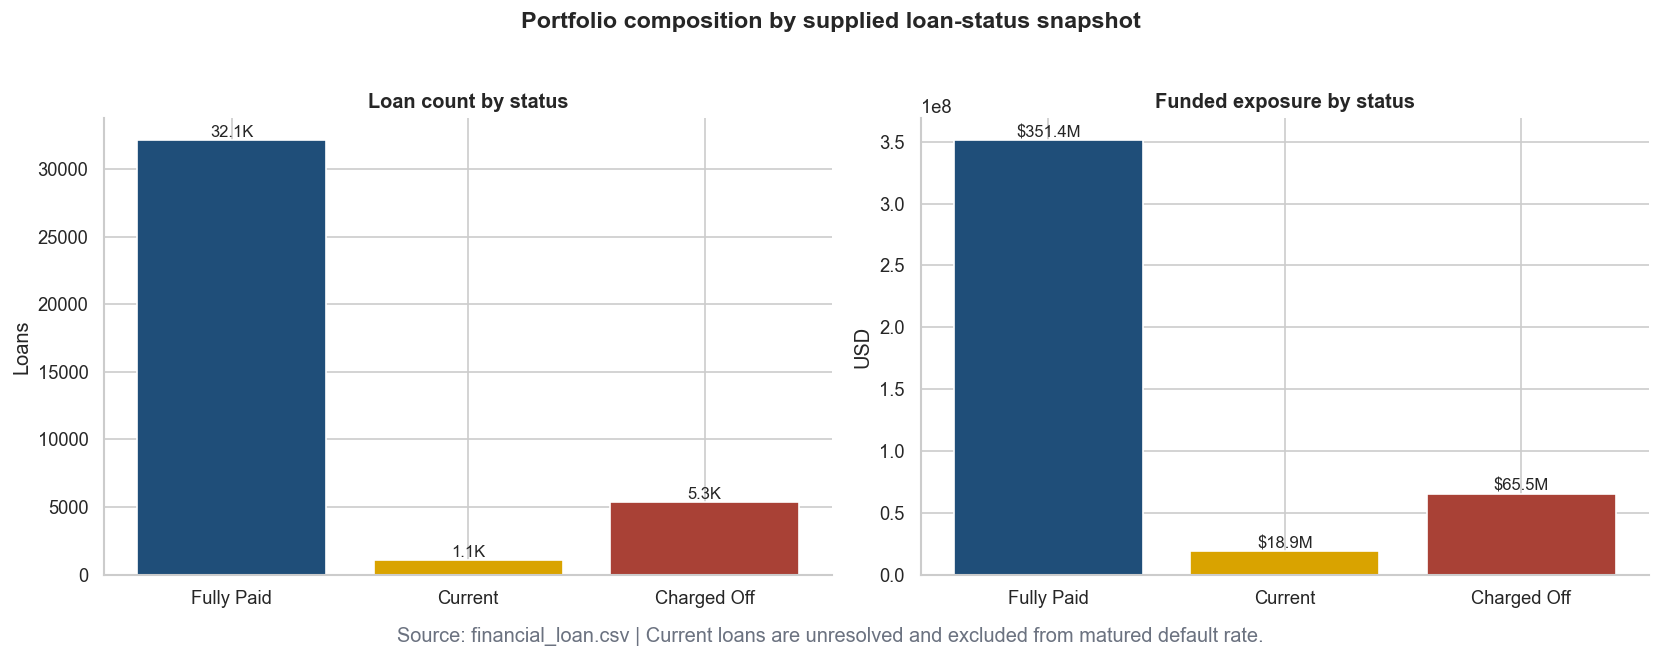

,loan_status,loan_count,funded_exposure,loan_share,funded_share
0,Fully Paid,"32,145","$351,358,350",83.3%,80.6%
1,Current,"1,098","$18,866,500",2.8%,4.3%
2,Charged Off,"5,333","$65,532,225",13.8%,15.0%


In [3]:
status_order = ['Fully Paid', 'Current', 'Charged Off']
status_summary = (
    df.groupby('loan_status')
    .agg(loan_count=('id', 'nunique'), funded_exposure=('loan_amount', 'sum'))
    .reindex(status_order)
    .reset_index()
)
status_summary['loan_share'] = status_summary['loan_count'] / len(df)
status_summary['funded_share'] = status_summary['funded_exposure'] / PORTFOLIO_FUNDED

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [PALETTE['blue'], PALETTE['gold'], PALETTE['red']]
for ax, value_col, title, formatter in [
    (axes[0], 'loan_count', 'Loan count by status', lambda value: f'{value/1000:.1f}K'),
    (axes[1], 'funded_exposure', 'Funded exposure by status', lambda value: f'${value/1e6:.1f}M'),
]:
    bars = ax.bar(status_summary['loan_status'], status_summary[value_col], color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Loans' if value_col == 'loan_count' else 'USD')
    for bar, value in zip(bars, status_summary[value_col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), formatter(value), ha='center', va='bottom', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Portfolio composition by supplied loan-status snapshot', y=1.03, fontsize=14, fontweight='bold')
fig.text(0.5, -0.02, 'Source: financial_loan.csv | Current loans are unresolved and excluded from matured default rate.', ha='center', color=PALETTE['neutral'])
plt.tight_layout()
plt.show()
display(status_summary.style.format({'loan_count': '{:,.0f}', 'funded_exposure': '${:,.0f}', 'loan_share': '{:.1%}', 'funded_share': '{:.1%}'}))

### 2. How does observed outcome risk vary by grade and sub-grade?
The interval chart makes denominator uncertainty visible. The table surfaces sub-grades with enough resolved-loan volume for review.

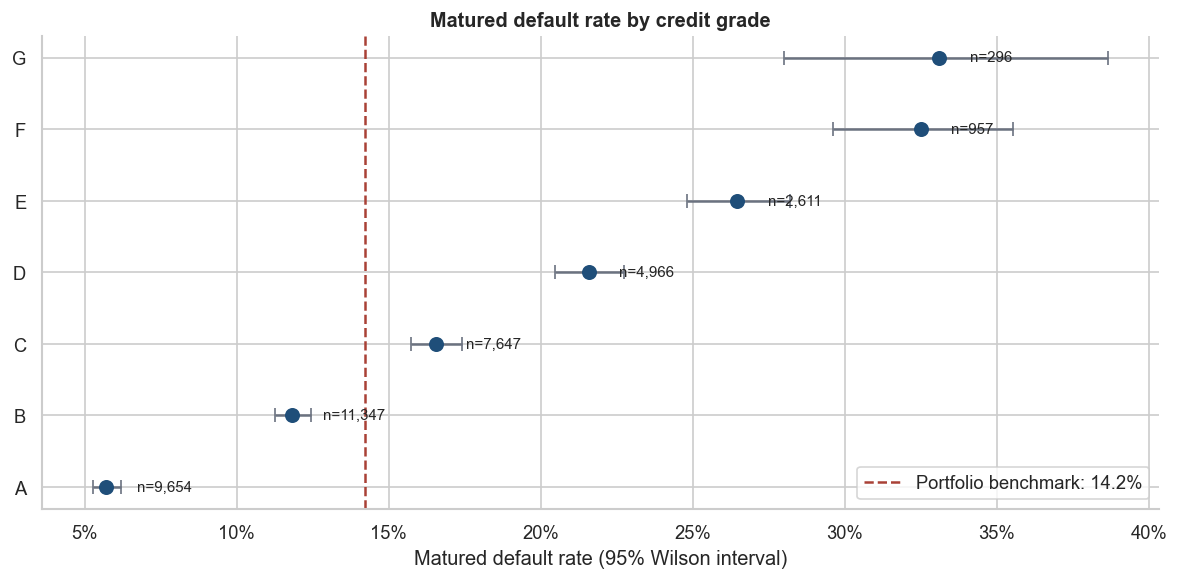

,sub_grade,loan_count,funded_exposure,resolved_loans,charged_off_loans,current_loans,matured_default_rate,ci_low,ci_high,funded_exposure_share,default_rate_vs_portfolio_pp,risk_exposure_proxy,review_priority,priority
29,F5,115,"$2,349,425",110,53,5,48.2%,39.1%,57.4%,0.005392,+34.0 pp,"$1,131,996",Watch: small segment,Watch: small segment
28,F4,163,"$3,003,950",147,52,16,35.4%,28.1%,43.4%,0.006894,+21.1 pp,"$1,062,622",Watch: small segment,Watch: small segment
25,F1,325,"$5,887,725",301,89,24,29.6%,24.7%,35.0%,0.013511,+15.3 pp,"$1,740,889",Watch: small segment,Watch: small segment
26,F2,243,"$4,361,475",227,67,16,29.5%,24.0%,35.8%,0.010009,+15.3 pp,"$1,287,308",Watch: small segment,Watch: small segment
23,E4,448,"$7,498,075",418,123,30,29.4%,25.3%,34.0%,0.017207,+15.2 pp,"$2,206,371",Watch: small segment,Watch: small segment
27,F3,182,"$3,307,875",172,50,10,29.1%,22.8%,36.3%,0.007591,+14.8 pp,"$961,592",Watch: small segment,Watch: small segment
24,E5,410,"$7,466,825",381,106,29,27.8%,23.6%,32.5%,0.017135,+13.6 pp,"$2,077,384",Watch: small segment,Watch: small segment
20,E1,750,"$11,093,725",711,193,39,27.1%,24.0%,30.5%,0.025459,+12.9 pp,"$3,011,377",High,High
21,E2,640,"$9,681,000",599,156,41,26.0%,22.7%,29.7%,0.022217,+11.8 pp,"$2,521,262",High,High
19,D5,851,"$11,950,900",811,202,40,24.9%,22.1%,28.0%,0.027426,+10.7 pp,"$2,976,673",High,High


In [4]:
grade_summary = segment_summary(df, ['grade']).sort_values('grade').reset_index(drop=True)
subgrade_summary = segment_summary(df, ['sub_grade']).sort_values(['matured_default_rate', 'resolved_loans'], ascending=[False, False])

fig, ax = plt.subplots(figsize=(10, 5))
y_positions = np.arange(len(grade_summary))
rate_pct = grade_summary['matured_default_rate'] * 100
lower_err = (grade_summary['matured_default_rate'] - grade_summary['ci_low']) * 100
upper_err = (grade_summary['ci_high'] - grade_summary['matured_default_rate']) * 100
ax.errorbar(rate_pct, y_positions, xerr=[lower_err, upper_err], fmt='o', color=PALETTE['blue'], ecolor=PALETTE['neutral'], capsize=4, markersize=8)
ax.axvline(PORTFOLIO_MATURED_RATE * 100, color=PALETTE['red'], linestyle='--', linewidth=1.5, label=f'Portfolio benchmark: {PORTFOLIO_MATURED_RATE:.1%}')
ax.set_yticks(y_positions, grade_summary['grade'])
ax.set_xlabel('Matured default rate (95% Wilson interval)')
ax.set_title('Matured default rate by credit grade')
ax.xaxis.set_major_formatter(lambda value, pos: f'{value:.0f}%')
for y, row in grade_summary.iterrows():
    ax.text(row['matured_default_rate'] * 100 + 1, y, f"n={row['resolved_loans']:,.0f}", va='center', fontsize=9)
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

display(subgrade_summary.query('resolved_loans >= 100').head(10).style.format({
    'loan_count': '{:,.0f}', 'resolved_loans': '{:,.0f}', 'charged_off_loans': '{:,.0f}',
    'funded_exposure': '${:,.0f}', 'matured_default_rate': '{:.1%}',
    'ci_low': '{:.1%}', 'ci_high': '{:.1%}', 'default_rate_vs_portfolio_pp': '{:+.1f} pp',
    'risk_exposure_proxy': '${:,.0f}'
}))

### 3. Which grades combine material exposure with elevated outcome risk?
A grade should be prioritized only when both its exposure and observed risk justify review. Bubble size is total loan count; the dashed lines are portfolio benchmarks.

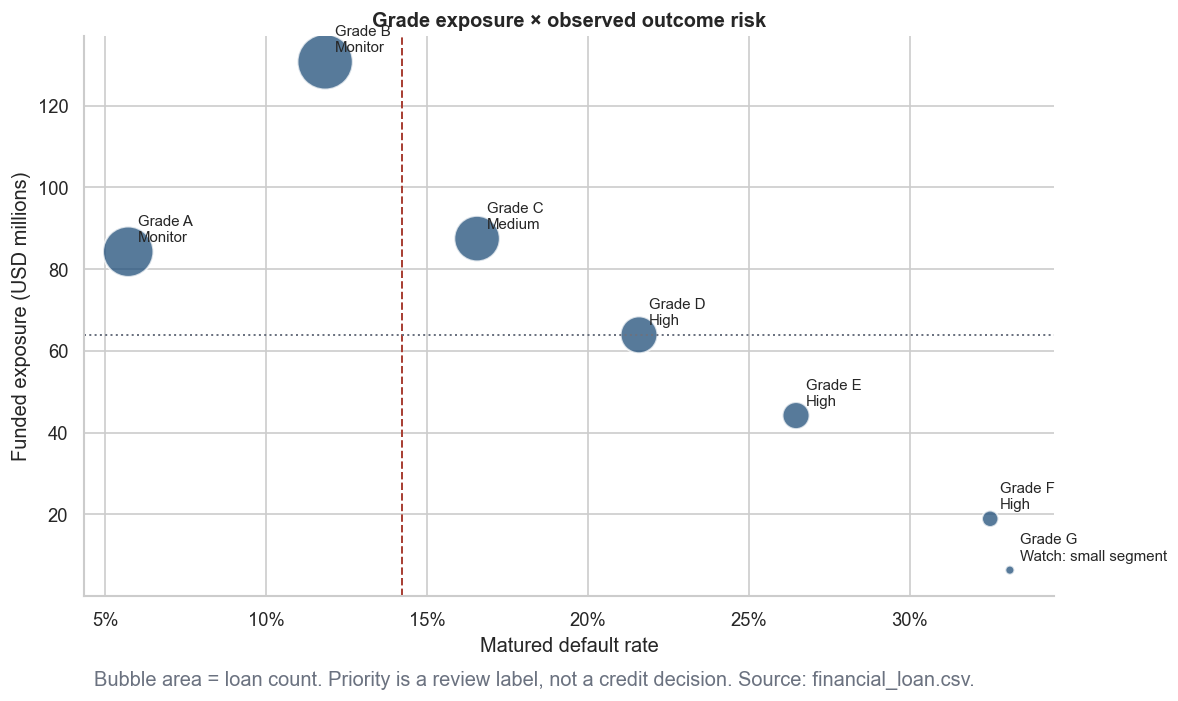

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
sizes = grade_summary['loan_count'] / grade_summary['loan_count'].max() * 1100
ax.scatter(grade_summary['matured_default_rate'] * 100, grade_summary['funded_exposure'] / 1e6, s=sizes, color=PALETTE['blue'], alpha=0.75, edgecolor='white', linewidth=1.2)
ax.axvline(PORTFOLIO_MATURED_RATE * 100, color=PALETTE['red'], linestyle='--', linewidth=1.2)
ax.axhline(grade_summary['funded_exposure'].median() / 1e6, color=PALETTE['neutral'], linestyle=':', linewidth=1.2)
for _, row in grade_summary.iterrows():
    ax.annotate(f"Grade {row['grade']}\n{row['priority']}", (row['matured_default_rate'] * 100, row['funded_exposure'] / 1e6), xytext=(6, 6), textcoords='offset points', fontsize=9)
ax.set_xlabel('Matured default rate')
ax.set_ylabel('Funded exposure (USD millions)')
ax.xaxis.set_major_formatter(lambda value, pos: f'{value:.0f}%')
ax.set_title('Grade exposure × observed outcome risk')
ax.text(0.01, -0.16, 'Bubble area = loan count. Priority is a review label, not a credit decision. Source: financial_loan.csv.', transform=ax.transAxes, color=PALETTE['neutral'])
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 4. Which states combine high funded exposure and above-benchmark risk?
This replaces a volume-only map with a risk matrix. State is a monitoring dimension, not evidence of geographic causality.

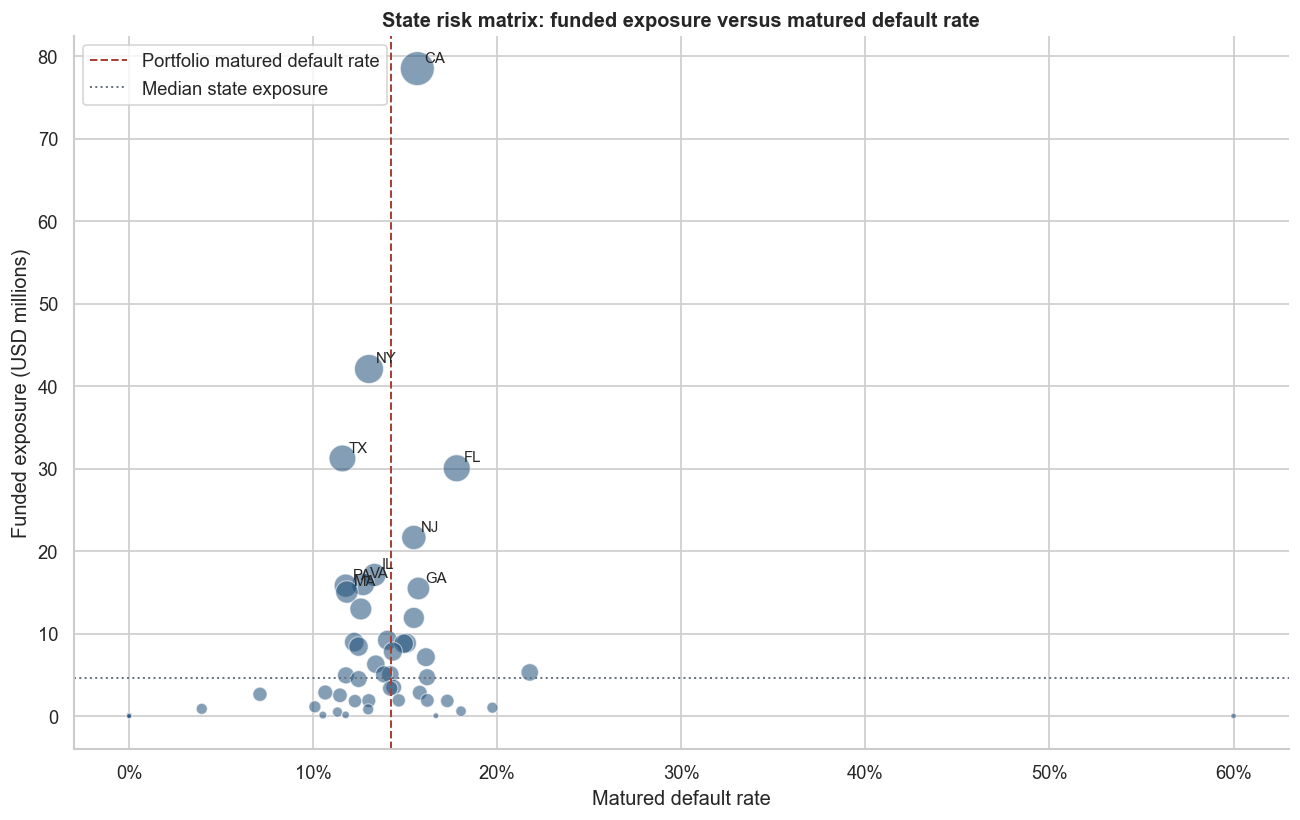

,address_state,loan_count,funded_exposure,resolved_loans,charged_off_loans,current_loans,matured_default_rate,ci_low,ci_high,funded_exposure_share,default_rate_vs_portfolio_pp,risk_exposure_proxy,review_priority,priority
0,CA,"6,894","$78,484,125","6,751",1057,143,15.7%,14.8%,16.5%,18.0%,+1.4 pp,"$12,288,212",Medium,Medium
1,NY,"3,701","$42,077,050","3,591",468,110,13.0%,12.0%,14.2%,9.7%,-1.2 pp,"$5,483,726",Monitor,Monitor
2,TX,"2,664","$31,236,650","2,597",301,67,11.6%,10.4%,12.9%,7.2%,-2.6 pp,"$3,620,420",Monitor,Monitor
3,FL,"2,773","$30,046,125","2,691",479,82,17.8%,16.4%,19.3%,6.9%,+3.6 pp,"$5,348,233",High,High
4,NJ,"1,822","$21,657,475","1,765",273,57,15.5%,13.9%,17.2%,5.0%,+1.2 pp,"$3,349,853",Medium,Medium
5,IL,"1,486","$17,124,225","1,440",192,46,13.3%,11.7%,15.2%,3.9%,-0.9 pp,"$2,283,230",Monitor,Monitor
6,VA,"1,375","$15,982,650","1,337",170,38,12.7%,11.0%,14.6%,3.7%,-1.5 pp,"$2,032,199",Monitor,Monitor
7,PA,"1,482","$15,826,525","1,436",169,46,11.8%,10.2%,13.5%,3.6%,-2.5 pp,"$1,862,592",Monitor,Monitor
8,GA,"1,355","$15,480,325","1,317",207,38,15.7%,13.9%,17.8%,3.6%,+1.5 pp,"$2,433,126",Medium,Medium
9,MA,"1,310","$15,051,000","1,268",150,42,11.8%,10.2%,13.7%,3.5%,-2.4 pp,"$1,780,481",Monitor,Monitor


In [6]:
state_summary = segment_summary(df, ['address_state']).sort_values('funded_exposure', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 7))
sizes = np.sqrt(state_summary['loan_count']) * 5
ax.scatter(state_summary['matured_default_rate'] * 100, state_summary['funded_exposure'] / 1e6, s=sizes, color=PALETTE['blue'], alpha=0.55, edgecolor='white', linewidth=0.7)
ax.axvline(PORTFOLIO_MATURED_RATE * 100, color=PALETTE['red'], linestyle='--', linewidth=1.2, label='Portfolio matured default rate')
ax.axhline(state_summary['funded_exposure'].median() / 1e6, color=PALETTE['neutral'], linestyle=':', linewidth=1.2, label='Median state exposure')
for _, row in state_summary.head(10).iterrows():
    ax.annotate(row['address_state'], (row['matured_default_rate'] * 100, row['funded_exposure'] / 1e6), xytext=(4, 4), textcoords='offset points', fontsize=9)
ax.set_xlabel('Matured default rate')
ax.set_ylabel('Funded exposure (USD millions)')
ax.xaxis.set_major_formatter(lambda value, pos: f'{value:.0f}%')
ax.set_title('State risk matrix: funded exposure versus matured default rate')
ax.legend(loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

display(state_summary.head(10).style.format({
    'loan_count': '{:,.0f}', 'resolved_loans': '{:,.0f}', 'funded_exposure': '${:,.0f}',
    'matured_default_rate': '{:.1%}', 'ci_low': '{:.1%}', 'ci_high': '{:.1%}',
    'funded_exposure_share': '{:.1%}', 'default_rate_vs_portfolio_pp': '{:+.1f} pp',
    'risk_exposure_proxy': '${:,.0f}'
}))

### 5. Which purpose × term combinations merit review?
The heatmap shows outcome risk; the companion table preserves exposure and denominators so a high rate in a small cell is not over-interpreted.

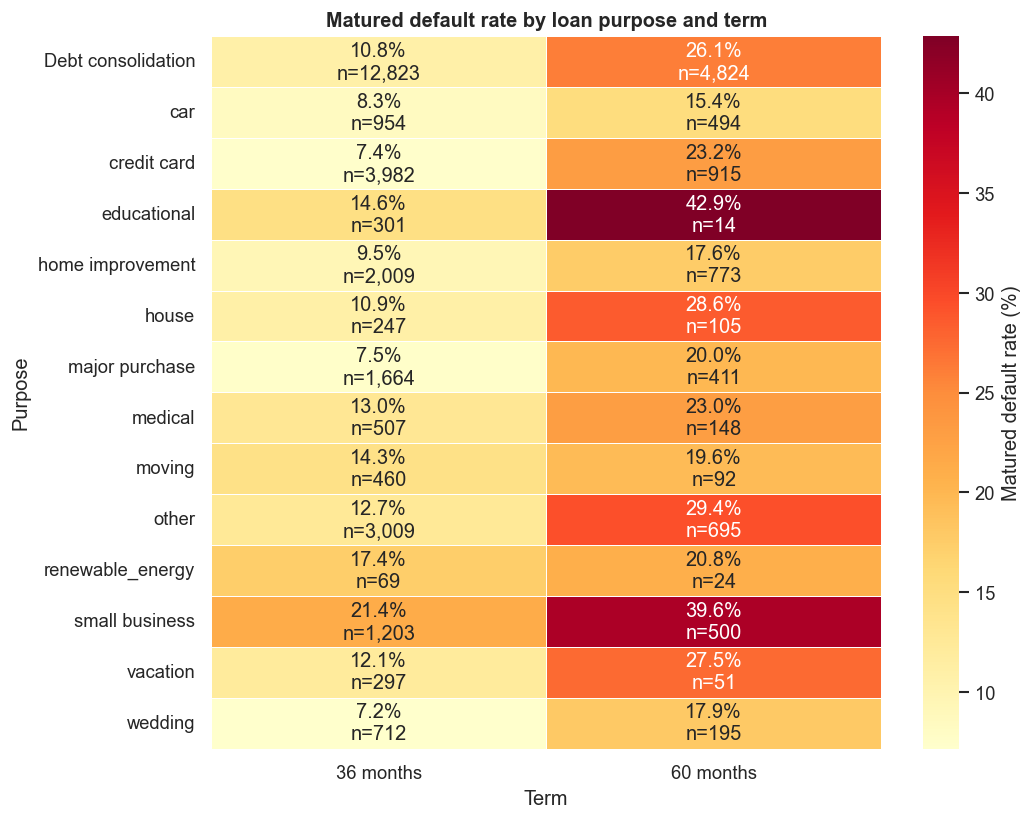

,purpose,term,loan_count,funded_exposure,resolved_loans,charged_off_loans,current_loans,matured_default_rate,ci_low,ci_high,funded_exposure_share,default_rate_vs_portfolio_pp,risk_exposure_proxy,review_priority,priority
1,Debt consolidation,60 months,"5,391","$92,775,900","4,824",1260,567,26.1%,0.248991,0.273777,0.212907,+11.9 pp,"$24,232,511",High,High
0,Debt consolidation,36 months,"12,823","$139,683,775","12,823",1391,0,10.8%,0.103211,0.113977,0.320554,-3.4 pp,"$15,152,471",Monitor,Monitor
23,small business,60 months,573,"$10,181,175",500,198,73,39.6%,0.354082,0.439504,0.023364,+25.4 pp,"$4,031,745",High,High
5,credit card,60 months,"1,016","$17,122,450",915,212,101,23.2%,0.205512,0.260119,0.039294,+8.9 pp,"$3,967,169",High,High
4,credit card,36 months,"3,982","$41,762,725","3,982",296,0,7.4%,0.066591,0.082899,0.095839,-6.8 pp,"$3,104,412",Monitor,Monitor
22,small business,36 months,"1,203","$13,941,925","1,203",257,0,21.4%,0.191402,0.237686,0.031995,+7.1 pp,"$2,978,449",High,High
19,other,60 months,815,"$9,861,000",695,204,120,29.4%,0.260879,0.328441,0.022630,+15.1 pp,"$2,894,452",High,High
18,other,36 months,"3,009","$21,294,750","3,009",383,0,12.7%,0.115850,0.139671,0.048868,-1.5 pp,"$2,710,498",Monitor,Monitor
9,home improvement,60 months,867,"$14,279,700",773,136,94,17.6%,0.150717,0.204364,0.032770,+3.4 pp,"$2,512,340",High,High
8,home improvement,36 months,"2,009","$19,071,075","2,009",191,0,9.5%,0.083008,0.108682,0.043765,-4.7 pp,"$1,813,129",Monitor,Monitor


In [7]:
purpose_term_summary = segment_summary(df, ['purpose', 'term'])
heatmap_rates = purpose_term_summary.pivot(index='purpose', columns='term', values='matured_default_rate') * 100
heatmap_n = purpose_term_summary.pivot(index='purpose', columns='term', values='resolved_loans')
annotations = heatmap_rates.copy().astype(object)
for purpose in heatmap_rates.index:
    for term in heatmap_rates.columns:
        rate = heatmap_rates.loc[purpose, term]
        n = heatmap_n.loc[purpose, term]
        annotations.loc[purpose, term] = '' if pd.isna(rate) else f'{rate:.1f}%\nn={n:,.0f}'

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heatmap_rates, annot=annotations, fmt='', cmap='YlOrRd', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Matured default rate (%)'}, ax=ax)
ax.set_title('Matured default rate by loan purpose and term')
ax.set_xlabel('Term')
ax.set_ylabel('Purpose')
plt.tight_layout()
plt.show()

display(purpose_term_summary.sort_values('risk_exposure_proxy', ascending=False).head(10).style.format({
    'loan_count': '{:,.0f}', 'resolved_loans': '{:,.0f}', 'funded_exposure': '${:,.0f}',
    'matured_default_rate': '{:.1%}', 'default_rate_vs_portfolio_pp': '{:+.1f} pp',
    'risk_exposure_proxy': '${:,.0f}'
}))

### 6. Are employment length and DTI bands associated with elevated observed risk?
Both panels include 95% intervals and resolved-loan denominators. These are descriptive borrower-profile comparisons, not underwriting thresholds.

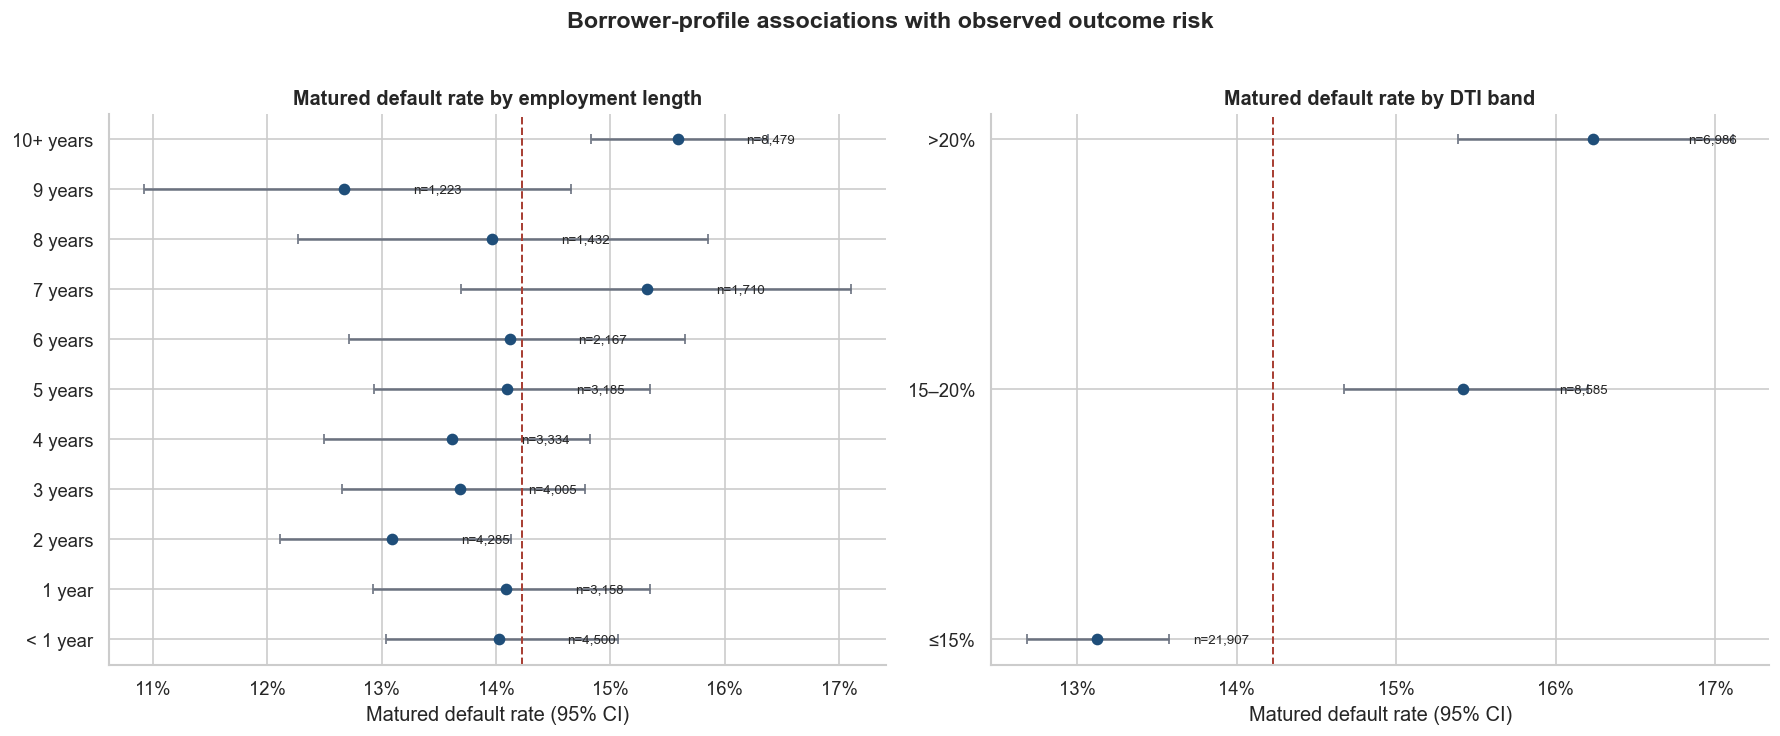

In [8]:
employment_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years']
employment_summary = segment_summary(df, ['emp_length']).set_index('emp_length').reindex(employment_order).reset_index().dropna(subset=['loan_count'])
dti_summary = segment_summary(df, ['dti_band']).sort_values('dti_band').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, summary, label_col, title in [
    (axes[0], employment_summary, 'emp_length', 'Matured default rate by employment length'),
    (axes[1], dti_summary, 'dti_band', 'Matured default rate by DTI band'),
]:
    y = np.arange(len(summary))
    rates = summary['matured_default_rate'] * 100
    lower = (summary['matured_default_rate'] - summary['ci_low']) * 100
    upper = (summary['ci_high'] - summary['matured_default_rate']) * 100
    ax.errorbar(rates, y, xerr=[lower, upper], fmt='o', color=PALETTE['blue'], ecolor=PALETTE['neutral'], capsize=3)
    ax.axvline(PORTFOLIO_MATURED_RATE * 100, color=PALETTE['red'], linestyle='--', linewidth=1.2)
    ax.set_yticks(y, summary[label_col].astype(str))
    ax.set_title(title)
    ax.set_xlabel('Matured default rate (95% CI)')
    ax.xaxis.set_major_formatter(lambda value, pos: f'{value:.0f}%')
    for position, (_, row) in enumerate(summary.iterrows()):
        ax.text(row['matured_default_rate'] * 100 + 0.6, position, f"n={row['resolved_loans']:,.0f}", va='center', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Borrower-profile associations with observed outcome risk', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Does the loan-status mix change by issue-month vintage?
The chart is a status-mix diagnostic, not a cohort default-rate comparison: later vintages have had less time to resolve and show more `Current` loans.

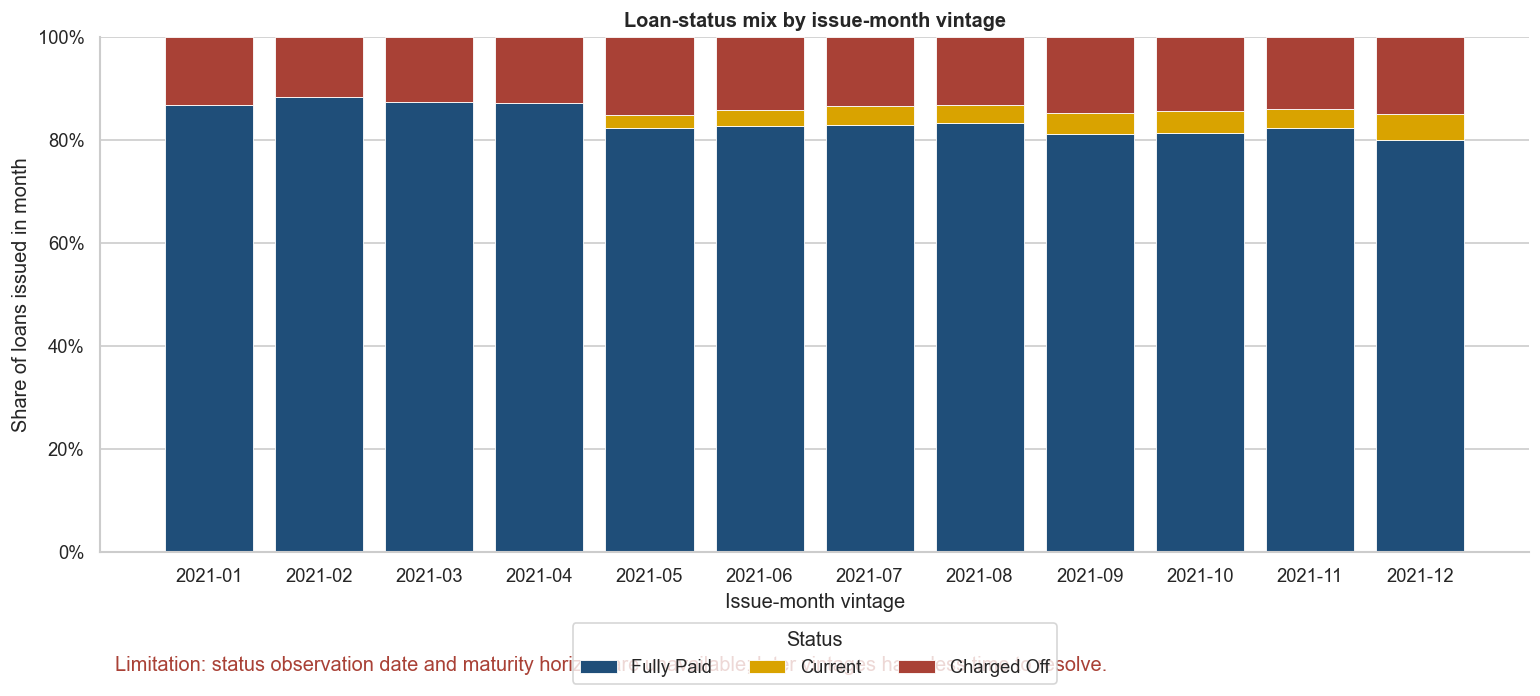

loan_status,Fully Paid,Current,Charged Off
issue_month,,,
2021-01,"2,023",0,309
2021-02,"2,015",0,264
2021-03,"2,293",1,333
2021-04,"2,400",3,352
2021-05,"2,394",78,439
2021-06,"2,635",96,453
2021-07,"2,793",119,454
2021-08,"2,867",122,452
2021-09,"2,867",148,521


In [9]:
vintage_counts = pd.crosstab(df['issue_month'], df['loan_status']).reindex(columns=status_order, fill_value=0)
vintage_mix = vintage_counts.div(vintage_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(vintage_mix))
for status, color in zip(status_order, colors):
    values = vintage_mix[status].values
    ax.bar(vintage_mix.index.astype(str), values, bottom=bottom, label=status, color=color, edgecolor='white', linewidth=0.5)
    bottom += values
ax.set_ylim(0, 100)
ax.set_ylabel('Share of loans issued in month')
ax.set_xlabel('Issue-month vintage')
ax.yaxis.set_major_formatter(lambda value, pos: f'{value:.0f}%')
ax.set_title('Loan-status mix by issue-month vintage')
ax.legend(title='Status', ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.text(0.01, -0.23, 'Limitation: status observation date and maturity horizon are unavailable; later vintages have less time to resolve.', transform=ax.transAxes, color=PALETTE['red'])
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
display(vintage_counts.style.format('{:,.0f}'))

### 8. Which segments are highest priority when risk is combined with exposure?
The table is the decision-facing evidence matrix. It deliberately retains rate, denominator, exposure, and priority instead of ranking only on a rate.

In [10]:
grade_segments = grade_summary.assign(segment_type='Grade', segment=lambda x: 'Grade ' + x['grade'].astype(str))
state_segments = state_summary.assign(segment_type='State', segment=state_summary['address_state'])
purpose_term_segments = purpose_term_summary.assign(segment_type='Purpose × Term', segment=purpose_term_summary['purpose'] + ' | ' + purpose_term_summary['term'].astype(str))
risk_segments = pd.concat([grade_segments, state_segments, purpose_term_segments], ignore_index=True, sort=False)
risk_columns = ['segment_type', 'segment', 'funded_exposure', 'matured_default_rate', 'loan_count', 'resolved_loans', 'default_rate_vs_portfolio_pp', 'risk_exposure_proxy', 'priority']
top_risk_segments = risk_segments[risk_columns].sort_values('risk_exposure_proxy', ascending=False).head(12).reset_index(drop=True)

evidence_matrix = risk_segments.loc[
    ((risk_segments['segment_type'] == 'Grade') & risk_segments['segment'].isin(['Grade A', 'Grade B', 'Grade C']))
    | ((risk_segments['segment_type'] == 'State') & risk_segments['segment'].eq('CA'))
    | ((risk_segments['segment_type'] == 'Purpose × Term') & risk_segments['segment'].eq('Debt consolidation | 60 months')),
    risk_columns,
].sort_values('risk_exposure_proxy', ascending=False)

print('Top risk segments by descriptive risk-exposure proxy')
display(top_risk_segments.style.format({
    'funded_exposure': '${:,.0f}', 'matured_default_rate': '{:.1%}', 'loan_count': '{:,.0f}',
    'resolved_loans': '{:,.0f}', 'default_rate_vs_portfolio_pp': '{:+.1f} pp',
    'risk_exposure_proxy': '${:,.0f}'
}).background_gradient(subset=['risk_exposure_proxy'], cmap='Blues'))

print('Required evidence matrix: selected high-risk and small-sample segments')
display(evidence_matrix.style.format({
    'funded_exposure': '${:,.0f}', 'matured_default_rate': '{:.1%}', 'loan_count': '{:,.0f}',
    'resolved_loans': '{:,.0f}', 'default_rate_vs_portfolio_pp': '{:+.1f} pp',
    'risk_exposure_proxy': '${:,.0f}'
}))

Top risk segments by descriptive risk-exposure proxy


,segment_type,segment,funded_exposure,matured_default_rate,loan_count,resolved_loans,default_rate_vs_portfolio_pp,risk_exposure_proxy,priority
0,Purpose × Term,Debt consolidation | 60 months,"$92,775,900",26.1%,"5,391","4,824",+11.9 pp,"$24,232,511",High
1,Grade,Grade B,"$130,703,975",11.8%,"11,674","11,347",-2.4 pp,"$15,469,766",Monitor
2,Purpose × Term,Debt consolidation | 36 months,"$139,683,775",10.8%,"12,823","12,823",-3.4 pp,"$15,152,471",Monitor
3,Grade,Grade C,"$87,456,450",16.6%,"7,904","7,647",+2.3 pp,"$14,478,863",Medium
4,Grade,Grade D,"$63,920,800",21.6%,"5,182","4,966",+7.4 pp,"$13,798,449",High
5,State,CA,"$78,484,125",15.7%,"6,894","6,751",+1.4 pp,"$12,288,212",Medium
6,Grade,Grade E,"$44,165,100",26.5%,"2,786","2,611",+12.2 pp,"$11,688,274",High
7,Grade,Grade F,"$18,910,450",32.5%,"1,028",957,+18.3 pp,"$6,145,402",High
8,State,NY,"$42,077,050",13.0%,"3,701","3,591",-1.2 pp,"$5,483,726",Monitor
9,State,FL,"$30,046,125",17.8%,"2,773","2,691",+3.6 pp,"$5,348,233",High


Required evidence matrix: selected high-risk and small-sample segments


,segment_type,segment,funded_exposure,matured_default_rate,loan_count,resolved_loans,default_rate_vs_portfolio_pp,risk_exposure_proxy,priority
58,Purpose × Term,Debt consolidation | 60 months,"$92,775,900",26.1%,"5,391","4,824",+11.9 pp,"$24,232,511",High
7,State,CA,"$78,484,125",15.7%,"6,894","6,751",+1.4 pp,"$12,288,212",Medium
5,Grade,Grade F,"$18,910,450",32.5%,"1,028",957,+18.3 pp,"$6,145,402",High
6,Grade,Grade G,"$6,348,075",33.1%,313,296,+18.9 pp,"$2,101,728",Watch: small segment


## Takeaways

1. **Prioritize Debt consolidation × 60 months.** It is the strongest decision-driving risk hypothesis because elevated outcomes, material exposure, adequate resolved-loan volume, and the cross-grade term pattern align.
2. **Treat the Grade A exposure gap as a testable opportunity.** Investigate demand, approval rates, requested amounts, policy limits, pricing, and risk-adjusted return before proposing greater allocation.
3. **Separate state risk from concentration.** Florida is the stronger grade-mix-adjusted risk signal; California warrants concentration monitoring because of its large funded exposure.
4. **Keep DTI above 20% as a supporting guardrail.** Do not set a hard DTI or employment-tenure policy from this descriptive EDA.
5. **Treat vintage results as incomplete.** Current-loan share rises in later issue months, consistent with right-censoring; an as-of date and maturity horizon are needed for a fair cohort comparison.

### Next steps
- Reconcile the primary tables with SQL and Power BI measures using `docs/metric_contract.md`.
- Perform a controlled segment drill-down (for example grade × term × purpose) before proposing a policy change.
- Obtain status observation date, maturity, loss, and cost data before estimating profitability or expected loss.